## Purpose
This notebook is to calculate stocks with a 14-day RSI of 75 and identify the first 25 highest RSI stocks.
This stock is considered overbought, meaning it may have risen too quickly, and a pullback could be imminent.

In [2]:
%matplotlib inline
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, current_date, date_sub
import configparser
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pyspark.sql import DataFrame
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.sql.types import DoubleType

In [3]:
config = configparser.ConfigParser()
config.read(os.path.join(os.path.dirname(os.path.abspath("__file__")), '../conf/config.ini'))
url = 'jdbc:mysql://localhost/{}'.format(config.get('mysql', 'database'))
driver = config.get('mysql', 'driver')
tablename = "stocksinfp"
username = config.get('mysql', 'username')
password = config.get('mysql', 'password')
print("url : ", url)
print("Driver : ", driver)
print("MySQL User : ", username)

url :  jdbc:mysql://localhost/stocksdb
Driver :  com.mysql.cj.jdbc.Driver
MySQL User :  quizadmin


In [4]:
spark = SparkSession.builder.appName("Best25Stocks") \
.master("local[*]") \
.config("spark.jars",
                "/Users/gaurav/.m2/repository/com/mysql/mysql-connector-j/8.0.33/mysql-connector-j-8.0.33.jar") \
.getOrCreate()

25/02/10 22:37:32 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
Using Spark's default log4j profile: org/apache/spark/log4j-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/02/10 22:37:34 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
25/02/10 22:37:34 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.
25/02/10 22:37:34 WARN Utils: Service 'SparkUI' could not bind on port 4042. Attempting port 4043.
25/02/10 22:37:34 WARN Utils: Service 'SparkUI' could not bind on port 4043. Attempting port 4044.


In [5]:
stock_df = spark.read.format("jdbc").options(url=url, driver=driver, user=username, password=password, dbtable=tablename).load()
#spark.sparkContext.stop()

In [6]:
# Filter for records in the last 1 year
one_year_ago = date_sub(current_date(), 180)
filtered_df = stock_df.filter(col("Date") >= one_year_ago)
#filtered_df = filtered_df.filter(col("Symbol") == 'AAPL')
# Show the result
filtered_df.printSchema()
filtered_df.show(2, truncate=False)

root
 |-- Date: date (nullable = true)
 |-- Open: string (nullable = true)
 |-- High: string (nullable = true)
 |-- Low: string (nullable = true)
 |-- Close: string (nullable = true)
 |-- Adj Close: string (nullable = true)
 |-- Volume: string (nullable = true)
 |-- symbol: string (nullable = true)
 |-- price_change: double (nullable = true)

+----------+------------------+------------------+------------------+------------------+------------------+--------+------+------------------+
|Date      |Open              |High              |Low               |Close             |Adj Close         |Volume  |symbol|price_change      |
+----------+------------------+------------------+------------------+------------------+------------------+--------+------+------------------+
|2024-08-14|220.57000732421875|223.02999877929688|219.6999969482422 |221.72000122070312|221.72000122070312|41960600|AAPL  |0.4499969482421875|
|2024-08-14|191.0             |193.35000610351562|190.47000122070312|193.0         

In [9]:
# Function to calculate the 14-day RSI
def calculate_rsi(df, window_size=14):
    # Calculate price change
    #df = df.withColumn('price_change', F.col('Close') - F.lag('Close', 1).over(Window.partitionBy('symbol').orderBy('Date')))

    # Calculate gain and loss
    df = df.withColumn('gain', F.when(F.col('price_change') > 0, F.col('price_change')).otherwise(0))
    df = df.withColumn('loss', F.when(F.col('price_change') < 0, -F.col('price_change')).otherwise(0))

    # Calculate rolling average gain and loss
    window_spec = Window.partitionBy('symbol').orderBy('Date').rowsBetween(-window_size + 1, 0)
    
    df = df.withColumn('avg_gain', F.avg('gain').over(window_spec))
    df = df.withColumn('avg_loss', F.avg('loss').over(window_spec))

    # Calculate RS (Relative Strength) and RSI
    df = df.withColumn('rs', F.col('avg_gain') / F.col('avg_loss'))
    df = df.withColumn('rsi', 100 - (100 / (1 + F.col('rs'))))

    return df

In [11]:
# Apply RSI calculation
df_rsi = calculate_rsi(filtered_df)

In [12]:
# Show the result
df_rsi.select('symbol', 'Date', 'rsi').show(10)

+------+----------+-----------------+
|symbol|      Date|              rsi|
+------+----------+-----------------+
|  AAPL|2024-08-14|             null|
|  AAPL|2024-08-15|             null|
|  AAPL|2024-08-16|             null|
|  AAPL|2024-08-19|96.43644841074298|
|  AAPL|2024-08-20|96.86881324856893|
|  AAPL|2024-08-21|94.82750556857977|
|  AAPL|2024-08-22|69.81663617776822|
|  AAPL|2024-08-23|77.23403426412007|
|  AAPL|2024-08-26|78.02873167063542|
|  AAPL|2024-08-27|79.79225562154733|
+------+----------+-----------------+
only showing top 10 rows



In [17]:
# Step 1: Filter for RSI > 75
filtered_df = df_rsi.filter(df_rsi['rsi'] > 75)

# Step 2: Get the latest available record for each stock symbol
window_spec = Window.partitionBy('symbol').orderBy(F.col('Date').desc())  # Window by symbol, ordered by date (latest first)

latest_rsi_df = filtered_df.withColumn('row_num', F.row_number().over(window_spec)) \
                            .filter(F.col('row_num') == 1) \
                            .drop('row_num')  # We keep only the latest row for each symbol

# Step 3: Get the top 25 stocks with the highest RSI
top_25_rsi_stocks = latest_rsi_df.orderBy(F.col('rsi').desc()).limit(25)

# Show the result
top_25_rsi_stocks.select('symbol', 'Date', 'rsi').show()


+------+----------+-----------------+
|symbol|      Date|              rsi|
+------+----------+-----------------+
|   RHE|2025-01-06|96.41909920564025|
|  META|2025-02-05| 94.1442736025291|
|   HCA|2024-09-05|93.86024844720497|
|  RBLX|2025-02-05|93.73604157083692|
|  ATOS|2024-08-26|92.00000762939453|
|    UI|2025-01-24|91.99067455734152|
|  DOCS|2025-02-07|91.72390582978443|
|  DASH|2025-02-07|91.45659845081575|
|  USEG|2025-01-21|90.94340315235306|
|   LLY|2025-02-07|90.93740431015708|
|  SRNE|2025-02-04|90.90908979063792|
|  NFLX|2025-02-07|89.91342645094097|
|  MVIS|2024-12-30|89.47368718250328|
|    DQ|2025-01-07|89.05473014499327|
|  APPS|2025-02-07|88.97850310021119|
|  PINS|2025-02-07|88.65306444021178|
|   NET|2025-02-07|87.93687198373269|
|    BB|2025-02-07|87.49999822605231|
|  BGNE|2025-02-06|86.98522569194608|
|  FTNT|2025-02-07|86.95651078549147|
+------+----------+-----------------+
only showing top 20 rows



/var/folders/cq/7_5990l175q3y4_djyh7dmsr0000gn/T/ipykernel_47824/3445727300.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='rsi', y='symbol', data=top_25_rsi_pandas, palette='coolwarm')


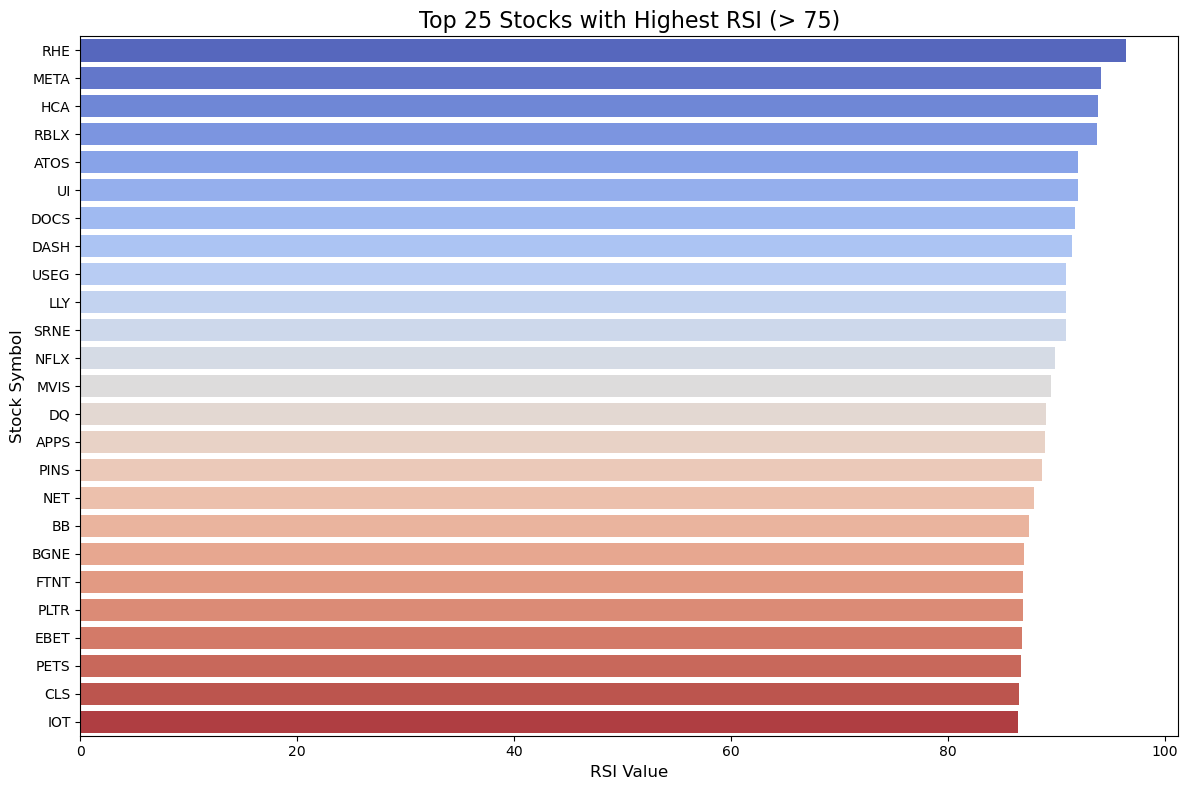

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Convert the Spark DataFrame to Pandas DataFrame
top_25_rsi_pandas = top_25_rsi_stocks.toPandas()

# Step 2: Create the bar plot
plt.figure(figsize=(12, 8))
sns.barplot(x='rsi', y='symbol', data=top_25_rsi_pandas, palette='coolwarm')

# Add labels and title
plt.title('Top 25 Stocks with Highest RSI (> 75)', fontsize=16)
plt.xlabel('RSI Value', fontsize=12)
plt.ylabel('Stock Symbol', fontsize=12)

# Show the plot
plt.tight_layout()
plt.show()
